In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

In [29]:
REPO_ROOT = Path("/home/kendra/Code/Learning_Value_Function_Manifold")
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from torchdiffeq import odeint

from lvfm.models import Decoder, PNODE_MLP, INR_PNODE, DeepReachModel, DeepReachExact
from lvfm.residuals import LinearOscillator2DResidual
from lvfm.managers import LossManager
from lvfm.hj_solvers import solve_linear_oscillator_2d

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ----------------------------
# run locations
# ----------------------------
RUN_ROOT = REPO_ROOT / "scripts" / "runs" / "linear_oscillator_2d"

CNFROM_RUNS = {
    "cnfrom_1": RUN_ROOT / "cnfrom_1",
    "cnfrom_2": RUN_ROOT / "cnfrom_2",
    "cnfrom_16": RUN_ROOT / "cnfrom_16",
    "cnfrom_128": RUN_ROOT / "cnfrom_128",
}

DEEPREACH_RUN = RUN_ROOT / "deepreach"

from pathlib import Path

OUTPUT_DIR = REPO_ROOT / "scripts" / "runs" / "linear_oscillator_2d" / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR)

# ----------------------------
# helpers
# ----------------------------
def to_namespace(d):
    return SimpleNamespace(**d)

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def load_cfg_from_run(run_dir):
    return to_namespace(load_yaml(Path(run_dir) / "config.yaml"))

def tau_ckpt_name(tau: float) -> str:
    if abs(float(tau)) < 1e-12:
        return "pretrain.pt"
    return f"tau_{float(tau):.2f}.pt"

def build_linear_residual(cfg):
    return LinearOscillator2DResidual(
        oscillation_speed=cfg.omega,
        control_bound=cfg.u_bound,
        disturbance_bound=cfg.d_bound,
        radius=cfg.beta,
        T=cfg.T,
        x1_bounds=cfg.x1_bounds,
        x2_bounds=cfg.x2_bounds,
        scale_to_minus1_1=cfg.scale_to_minus1_1,
        scale_time_to_01=cfg.scale_time_to_01,
    )

def build_cnfrom_model(cfg, device=DEVICE):
    residual = build_linear_residual(cfg)
    loss_manager = LossManager(
        residual=residual,
        loss_weights={"terminal": 1.0, "pinn": 1.0},
    )

    decoder = Decoder(
        hidden_dim=cfg.decoder_hidden_dim,
        latent_dim=cfg.latent_dim,
        coordinate_dim=cfg.coordinate_dim,
        out_dim=1,
        num_layers=cfg.decoder_num_layers,
        net_type=cfg.net_type,
        input_scale=getattr(cfg, "input_scale", 64.0),
        omega0=getattr(cfg, "omega0", 30.0),
    )

    pnode = PNODE_MLP(
        latent_dim=cfg.latent_dim,
        hidden_dim=cfg.pnode_hidden_dim,
        num_layers=getattr(cfg, "pnode_num_layers", 3),
        # omega0=getattr(cfg, "omega0", 15.0),
    )

    model = INR_PNODE(
        latent_dim=cfg.latent_dim,
        decoder=decoder,
        pnode=pnode,
        loss_manager=loss_manager,
        value_var=getattr(cfg, "value_var", 0.5),
        value_normto=getattr(cfg, "value_normto", 0.02),
        ode_solver=odeint,
        method=cfg.method,
        rtol=cfg.rtol,
        atol=cfg.atol,
        device=device,
    ).to(device)

    return model

def build_deepreach_model(cfg, wrapped=True, device=DEVICE):
    backbone = DeepReachModel(
        in_dim=cfg.in_dim,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        omega0=cfg.omega0,
    ).to(device)

    if not wrapped:
        return backbone

    residual = build_linear_residual(cfg)
    model = DeepReachExact(
        backbone=backbone,
        residual=residual,
        coordinate_dim=2,
        value_var=getattr(cfg, "value_var", 0.5),
        value_normto=getattr(cfg, "value_normto", 0.02),
    ).to(device)
    return model

def load_cnfrom_checkpoint(run_dir, ckpt_name, device=DEVICE):
    run_dir = Path(run_dir)
    cfg = load_cfg_from_run(run_dir)
    model = build_cnfrom_model(cfg, device=device)

    ckpt_path = run_dir / "ckpts" / ckpt_name
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()
    return model, cfg, ckpt

def load_deepreach_checkpoint(run_dir, ckpt_name, device=DEVICE):
    run_dir = Path(run_dir)
    cfg = load_cfg_from_run(run_dir)

    ckpt_path = run_dir / "ckpts" / ckpt_name
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["model_state_dict"]

    # saved from wrapped DeepReachExact
    if any(k.startswith("backbone.") for k in state_dict.keys()):
        model = build_deepreach_model(cfg, wrapped=True, device=device)
        model.load_state_dict(state_dict, strict=True)
    else:
        # saved from raw DeepReachModel
        model = build_deepreach_model(cfg, wrapped=False, device=device)
        model.load_state_dict(state_dict, strict=True)

    model.eval()
    return model, cfg, ckpt

def scale_states_to_net(x_phys, cfg):
    x = torch.tensor(x_phys, dtype=torch.float32)
    if getattr(cfg, "scale_to_minus1_1", True):
        x1_lo, x1_hi = cfg.x1_bounds
        x2_lo, x2_hi = cfg.x2_bounds
        x[:, 0] = 2.0 * (x[:, 0] - x1_lo) / (x1_hi - x1_lo) - 1.0
        x[:, 1] = 2.0 * (x[:, 1] - x2_lo) / (x2_hi - x2_lo) - 1.0
    return x

def scale_tau_to_net(tau, cfg, n):
    tau_vec = torch.full((n, 1), float(tau), dtype=torch.float32)
    if getattr(cfg, "scale_time_to_01", True):
        tau_vec = tau_vec / cfg.T
    return tau_vec

@torch.no_grad()
def evaluate_cnfrom_on_grid(model, cfg, tau, nx=201, device=DEVICE, chunk_size=4096):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)
    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    for start in range(0, xt.shape[0], chunk_size):
        end = min(start + chunk_size, xt.shape[0])
        xt_chunk = xt[start:end]
        tau_phys_chunk = torch.full((end - start,), float(tau), dtype=torch.float32, device=device)
        V_chunk = model.compute_value_at_xt(xt_chunk, tau_phys_chunk)[0]
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    return X1, X2, V_pred

@torch.no_grad()
def evaluate_deepreach_on_grid(model, cfg, tau, nx=201, device=DEVICE, chunk_size=4096):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)
    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    for start in range(0, xt.shape[0], chunk_size):
        end = min(start + chunk_size, xt.shape[0])
        xt_chunk = xt[start:end]
        V_chunk = model(xt_chunk)
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    return X1, X2, V_pred

def compute_ground_truth_slice(
    tau=1.0,
    nx=201,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    omega=1.0,
    u_bound=1.0,
    d_bound=0.5,
    beta=0.25,
):
    """
    Uses the same project solver as the training script.

    IMPORTANT:
    solve_linear_oscillator_2d([tau], ...) may return:
      [V(tau)]                OR
      [V(0), V(tau)]
    depending on the helper implementation.

    To be robust and to fix the tau=1.0 issue, we always take the LAST slice.
    """
    x1 = np.linspace(x1_bounds[0], x1_bounds[1], nx)
    x2 = np.linspace(x2_bounds[0], x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    gt = solve_linear_oscillator_2d(
        [float(tau)],
        nx,
        nx,
        x1_bounds,
        x2_bounds,
        u_bound,
        d_bound,
        omega,
        beta,
    )

    # robust: use final returned slice, not gt[0]
    V = np.array(gt[-1]).T
    return X1, X2, V

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)

def compute_mae(V_pred, V_gt):
    return np.mean(np.abs(V_pred - V_gt))

def plot_pairwise_comparison(tau=1.00, nx=201, save=True):
    """
    Panels in a 2x3 grid:
      Row 1: LatentReach 1 | LatentReach 2 | LatentReach 16
      Row 2: LatentReach 128 | DeepReach | Ground Truth
    """

    cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(tau=tau, nx=nx)

    # Expecting:
    # LatentReach 1, LatentReach 2, LatentReach 16, LatentReach 128, DeepReach
    # plus Ground Truth as final panel

    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=False)
    fig.subplots_adjust(hspace=0.05, wspace=0.6)
    axes = axes.flatten()

    # plot model panels
    for ax, (name, X1, X2, V) in zip(axes[:len(model_entries)], model_entries):
        vmin = np.nanmin(V)
        vmax = np.nanmax(V)
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6
        levels = np.linspace(vmin, vmax, 40)

        cf = ax.contourf(X1, X2, V, levels=levels)
        ax.contour(X1, X2, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(X1_gt, X2_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

        ax.set_title(name, fontsize=12)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_xlim(cfg_ref.x1_bounds)
        ax.set_ylim(cfg_ref.x2_bounds)
        ax.set_aspect("equal")

        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    # Ground truth in final panel
    gt_ax = axes[5]
    gt_vmin = np.nanmin(V_gt)
    gt_vmax = np.nanmax(V_gt)
    if np.isclose(gt_vmin, gt_vmax):
        gt_vmax = gt_vmin + 1e-6
    gt_levels = np.linspace(gt_vmin, gt_vmax, 40)

    cf = gt_ax.contourf(X1_gt, X2_gt, V_gt, levels=gt_levels)
    gt_ax.contour(X1_gt, X2_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

    gt_ax.set_title("Ground Truth", fontsize=12)
    gt_ax.set_xlabel(r"$x_1$")
    gt_ax.set_ylabel(r"$x_2$")
    gt_ax.set_xlim(cfg_ref.x1_bounds)
    gt_ax.set_ylim(cfg_ref.x2_bounds)
    gt_ax.set_aspect("equal")

    fig.colorbar(cf, ax=gt_ax, fraction=0.046, pad=0.03)

    # fig.suptitle(f"Linear oscillator comparison at $\\tau={tau:.2f}$", fontsize=16)

    if save:
        save_path = OUTPUT_DIR / f"pairwise_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

import pandas as pd

def compute_mse(V_pred, V_gt):
    return np.mean((V_pred - V_gt) ** 2)

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)
    
def evaluate_all_models_for_tau(tau=1.00, nx=201):
    """
    Returns:
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries
    where model_entries is a list of:
        (display_name, X1, X2, V)
    """

    _, cfg_ref, _ = load_cnfrom_checkpoint(
        CNFROM_RUNS["cnfrom_2"],
        tau_ckpt_name(min(float(tau), 1.00)),
        device=DEVICE,
    )

    X1_gt, X2_gt, V_gt = compute_ground_truth_slice(
        tau=tau,
        nx=nx,
        x1_bounds=cfg_ref.x1_bounds,
        x2_bounds=cfg_ref.x2_bounds,
        omega=cfg_ref.omega,
        u_bound=cfg_ref.u_bound,
        d_bound=cfg_ref.d_bound,
        beta=cfg_ref.beta,
    )

    model_entries = []

    latentreach_runs = [
        ("LatentReach 1", "cnfrom_1"),
        ("LatentReach 2", "cnfrom_2"),
        ("LatentReach 16", "cnfrom_16"),
        ("LatentReach 128", "cnfrom_128"),
    ]

    for display_name, run_key in latentreach_runs:
        run_dir = CNFROM_RUNS[run_key]
        ckpt_name = tau_ckpt_name(min(float(tau), 1.00))
        ckpt_path = run_dir / "ckpts" / ckpt_name
        if not ckpt_path.exists():
            ckpt_name = "tau_1.00.pt"

        model, cfg, _ = load_cnfrom_checkpoint(run_dir, ckpt_name, device=DEVICE)
        X1, X2, V = evaluate_cnfrom_on_grid(model, cfg, tau=tau, nx=nx, device=DEVICE)
        model_entries.append((display_name, X1, X2, V))

    deep_ckpt = DEEPREACH_RUN / "ckpts" / tau_ckpt_name(min(float(tau), 1.00))
    deep_ckpt_fallback = DEEPREACH_RUN / "ckpts" / "tau_1.00.pt"

    if deep_ckpt.exists():
        deep_ckpt_name = deep_ckpt.name
    elif deep_ckpt_fallback.exists():
        deep_ckpt_name = deep_ckpt_fallback.name
    else:
        deep_ckpt_name = None

    if deep_ckpt_name is not None:
        model, cfg, _ = load_deepreach_checkpoint(DEEPREACH_RUN, deep_ckpt_name, device=DEVICE)
        X1, X2, V = evaluate_deepreach_on_grid(model, cfg, tau=tau, nx=nx, device=DEVICE)
        model_entries.append(("DeepReach", X1, X2, V))

    return cfg_ref, X1_gt, X2_gt, V_gt, model_entries

def make_metrics_table(taus=[1.00], nx=201):
    rows = []

    for tau in taus:
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(tau=tau, nx=nx)

        for name, X1, X2, V in model_entries:
            rows.append({
                "tau": tau,
                "model": name,
                "MSE": compute_mse(V, V_gt),
                "IoU": compute_iou(V, V_gt),
            })

    df = pd.DataFrame(rows)
    return df

def plot_zero_level_overlay_row(
    taus=[0.05, 0.10, 0.20, 0.40, 0.70, 1.00],
    nx=401,
    save=True
):
    """
    Stacked BRT overlay figure in a 2x3 grid.
    Each panel shows the zero level set for all models plus ground truth.
    """

    colors = {
        "LatentReach 1": "tab:red",
        "LatentReach 2": "tab:green",
        "LatentReach 16": "tab:orange",
        "LatentReach 128": "tab:purple",
        "DeepReach": "tab:blue",
    }

    fig, axes = plt.subplots(
        2, 3,
        figsize=(14, 9),
        constrained_layout=False
    )
    axes = axes.flatten()

    # adjust spacing manually
    fig.subplots_adjust(hspace=0.15, wspace=0.35)

    legend_handles = [
        plt.Line2D([0], [0], color="black", lw=3.0, label="Ground Truth"),
        plt.Line2D([0], [0], color="tab:red", lw=2.0, label="LatentReach 1"),
        plt.Line2D([0], [0], color="tab:green", lw=2.0, label="LatentReach 2"),
        plt.Line2D([0], [0], color="tab:orange", lw=2.0, label="LatentReach 16"),
        plt.Line2D([0], [0], color="tab:purple", lw=2.0, label="LatentReach 128"),
        plt.Line2D([0], [0], color="tab:blue", lw=2.0, label="DeepReach"),
    ]

    for ax, tau in zip(axes, taus):
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(
            tau=tau, nx=nx
        )

        # ground truth
        ax.contour(
            X1_gt, X2_gt, V_gt,
            levels=[0.0],
            colors="black",
            linewidths=3.0
        )

        # models
        for name, X1, X2, V in model_entries:
            ax.contour(
                X1, X2, V,
                levels=[0.0],
                colors=colors[name],
                linewidths=2.0
            )

        ax.set_title(rf"$\tau={tau:.2f}$", fontsize=12)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_aspect("equal")
        ax.set_xlim(cfg_ref.x1_bounds)
        ax.set_ylim(cfg_ref.x2_bounds)

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.98)
    )
    # fig.suptitle("BRT overlay across time", fontsize=16)

    if save:
        save_path = OUTPUT_DIR / "brt_overlay_row.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

DEVICE: cuda
Saving outputs to: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs


100%|##################################|  1.0000/1.0 [00:01<00:00,  1.07s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/pairwise_tau_1.00.png


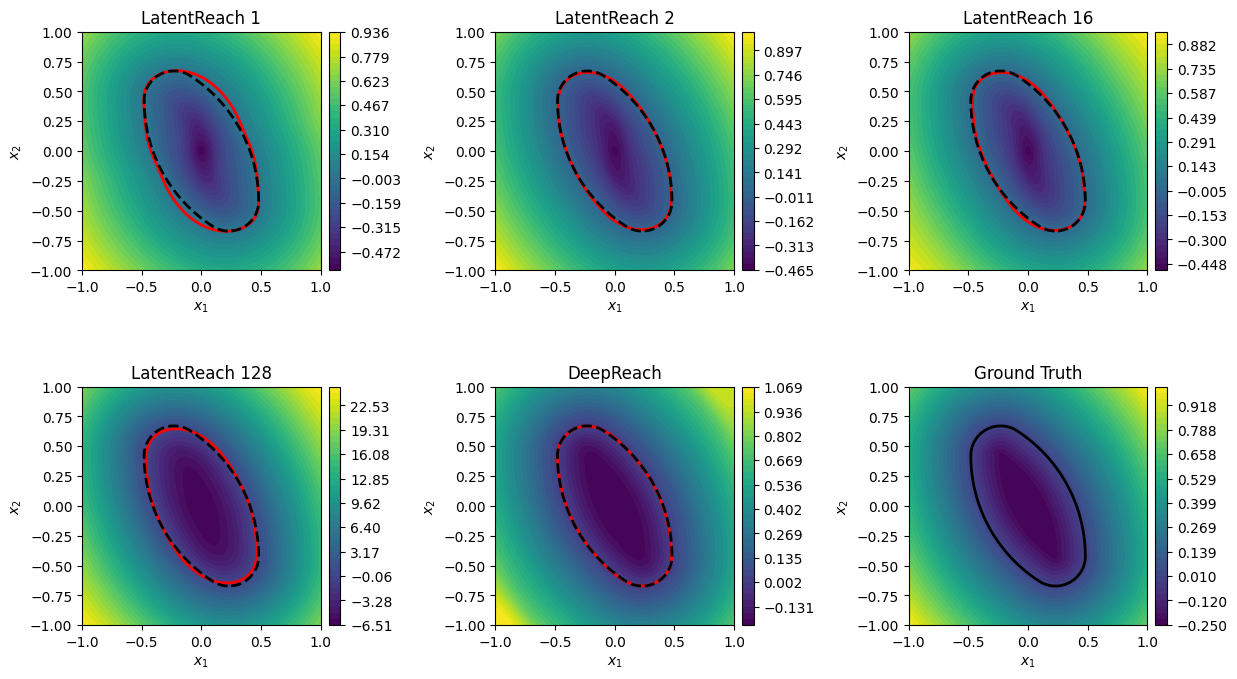

In [30]:
plot_pairwise_comparison(tau=1.00, nx=201)

100%|##################|  0.2000/0.20000000298023224 [00:00<00:00,  1.02s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/pairwise_tau_0.20.png


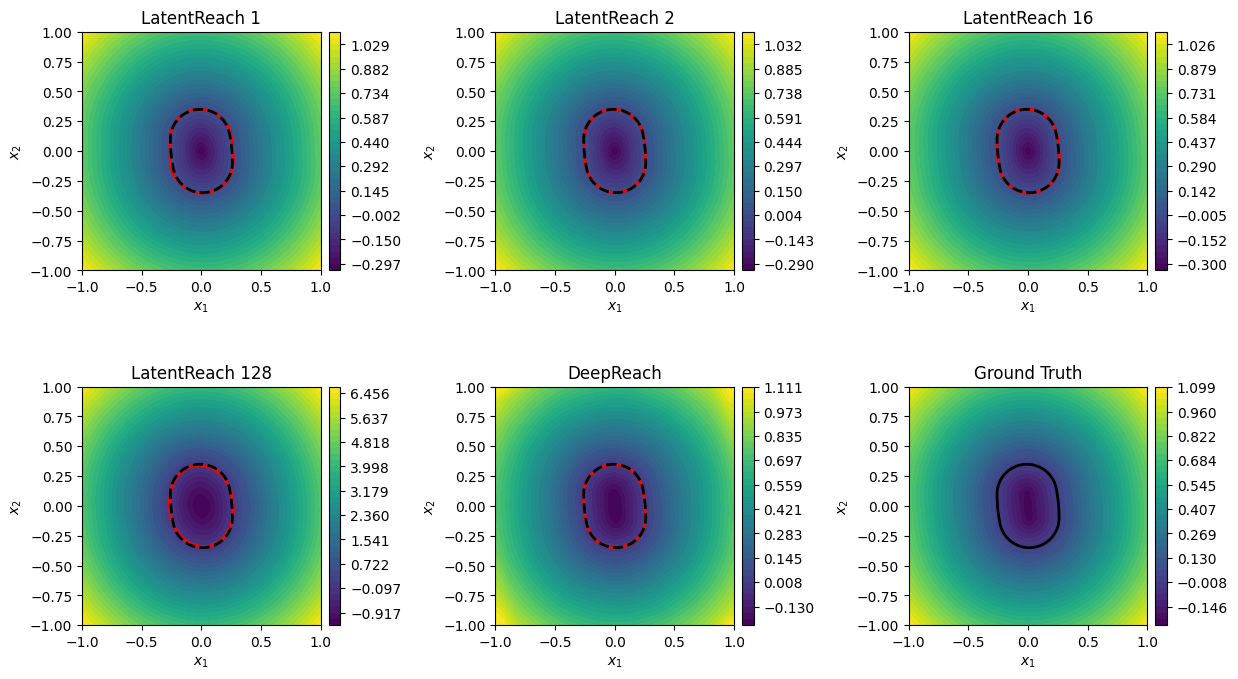

In [31]:
plot_pairwise_comparison(tau=0.2, nx=201)

In [32]:
metrics_df = make_metrics_table([1.00], nx=201)

combined_table = metrics_df.pivot(index="model", columns="tau", values=["MSE", "IoU"])

# optional: round for cleaner display
combined_table = combined_table.round({"MSE": 6, "IoU": 4})

display(combined_table)

latex_path = OUTPUT_DIR / "linear_oscillator_metrics_table.tex"

with open(latex_path, "w") as f:
    f.write(
        combined_table.to_latex(
            multicolumn=True,
            multirow=False,
            float_format="%.6f"
        )
    )

print("Saved:", latex_path)

100%|##################################|  1.0000/1.0 [00:01<00:00,  1.05s/sim_s]


,MSE,IoU
tau,1.0,1.0
model,,
DeepReach,0.000218,0.990180
LatentReach 1,0.002693,0.918747
LatentReach 128,92.260475,0.947495
LatentReach 16,0.000769,0.965684
LatentReach 2,0.000571,0.973666


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/linear_oscillator_metrics_table.tex


100%|##################|  0.0500/0.05000000074505806 [00:00<00:00,  4.87s/sim_s]
100%|##################|  0.1000/0.10000000149011612 [00:00<00:00,  5.08s/sim_s]
100%|##################|  0.2000/0.20000000298023224 [00:00<00:00,  4.86s/sim_s]
100%|###################|  0.4000/0.4000000059604645 [00:01<00:00,  4.83s/sim_s]
100%|####################|  0.7000/0.699999988079071 [00:03<00:00,  5.12s/sim_s]
100%|##################################|  1.0000/1.0 [00:04<00:00,  4.93s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/brt_overlay_row.png


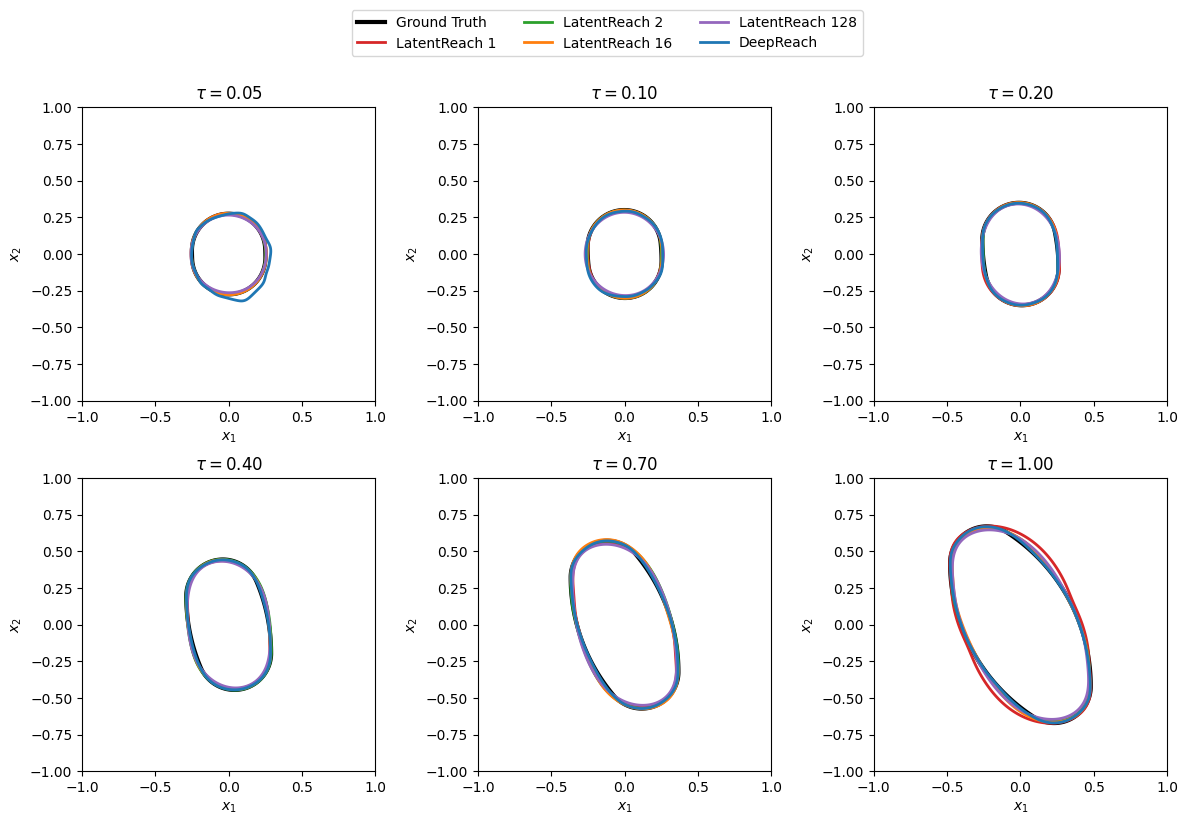

In [33]:
plot_zero_level_overlay_row(taus=[0.05, 0.10, 0.20, 0.40, 0.70, 1.00], nx=401)

# Dynamics

$$\dot{x} =
\begin{bmatrix}
\dot{x_1} \\
\dot{x_2}\\
\end{bmatrix}
=
\begin{bmatrix}
x_2\\
-w^2x_1 + u + d
\end{bmatrix}
$$

# Optimal

$$\max_{u\in U}\min_{d_\in D} \nabla_x V \cdot f(x)$$

$$\frac{\partial V}{\partial x_1} x_1 - \frac{\partial V}{\partial x_2}\omega^2x_1 + \min_u\frac{\partial V}{\partial x_2}u + \max_d \frac{\partial V}{\partial x_2}d$$

$$u^* = \text{argmin}_u \frac{\partial V}{\partial x_2}u$$
$$d^* = \text{argmax}_d \frac{\partial V}{\partial x_2}d$$


In [39]:
def compute_gt_gradients_from_grid(V_gt, cfg, nx):
    """
    V_gt shape: [nx, nx], using meshgrid indexing='xy'
    axis 0 corresponds to x2/y direction
    axis 1 corresponds to x1/x direction
    """
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)

    dx1 = x1[1] - x1[0]
    dx2 = x2[1] - x2[0]

    dV_dx2, dV_dx1 = np.gradient(V_gt, dx2, dx1, edge_order=2)

    grad_gt = np.stack([dV_dx1, dV_dx2], axis=-1)
    return grad_gt


def evaluate_cnfrom_value_and_grad_on_grid(
    model,
    cfg,
    tau,
    nx=201,
    device=DEVICE,
    chunk_size=4096,
):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)

    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt_all = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    grads = []

    model.eval()

    for start in range(0, xt_all.shape[0], chunk_size):
        end = min(start + chunk_size, xt_all.shape[0])

        xt = xt_all[start:end].clone().detach().requires_grad_(True)
        tau_phys = torch.full(
            (end - start,),
            float(tau),
            dtype=torch.float32,
            device=device,
        )

        V = model.compute_value_at_xt(xt, tau_phys)[0].squeeze(-1)

        dV_dxt = torch.autograd.grad(
            V,
            xt,
            grad_outputs=torch.ones_like(V),
            retain_graph=False,
            create_graph=False,
        )[0]

        grad_net = dV_dxt[:, :2]

        # convert dV/dx_net to dV/dx_phys
        grad_phys = grad_net.clone()

        if getattr(cfg, "scale_to_minus1_1", True):
            grad_phys[:, 0] = grad_net[:, 0] * (
                2.0 / (cfg.x1_bounds[1] - cfg.x1_bounds[0])
            )
            grad_phys[:, 1] = grad_net[:, 1] * (
                2.0 / (cfg.x2_bounds[1] - cfg.x2_bounds[0])
            )

        vals.append(V.detach().cpu().numpy())
        grads.append(grad_phys.detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    grad_pred = np.concatenate(grads, axis=0).reshape(nx, nx, 2)

    return X1, X2, V_pred, grad_pred


def evaluate_deepreach_value_and_grad_on_grid(
    model,
    cfg,
    tau,
    nx=201,
    device=DEVICE,
    chunk_size=4096,
):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)

    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt_all = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    grads = []

    model.eval()

    for start in range(0, xt_all.shape[0], chunk_size):
        end = min(start + chunk_size, xt_all.shape[0])

        xt = xt_all[start:end].clone().detach().requires_grad_(True)

        V = model(xt).squeeze(-1)

        dV_dxt = torch.autograd.grad(
            V,
            xt,
            grad_outputs=torch.ones_like(V),
            retain_graph=False,
            create_graph=False,
        )[0]

        grad_net = dV_dxt[:, :2]

        grad_phys = grad_net.clone()

        if getattr(cfg, "scale_to_minus1_1", True):
            grad_phys[:, 0] = grad_net[:, 0] * (
                2.0 / (cfg.x1_bounds[1] - cfg.x1_bounds[0])
            )
            grad_phys[:, 1] = grad_net[:, 1] * (
                2.0 / (cfg.x2_bounds[1] - cfg.x2_bounds[0])
            )

        vals.append(V.detach().cpu().numpy())
        grads.append(grad_phys.detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    grad_pred = np.concatenate(grads, axis=0).reshape(nx, nx, 2)

    return X1, X2, V_pred, grad_pred

def safe_sign(x, eps=1e-6):
    out = np.zeros_like(x)
    out[x > eps] = 1.0
    out[x < -eps] = -1.0
    return out


def optimal_control_linear_from_grad(grad, cfg, eps=1e-6):
    p2 = grad[..., 1]
    s = safe_sign(p2, eps=eps)

    u_star = -cfg.u_bound * s
    d_star =  cfg.d_bound * s

    return u_star, d_star


def gradient_and_control_metrics(V_pred, grad_pred, V_gt, grad_gt, cfg, boundary_band=0.05):
    grad_err = grad_pred - grad_gt

    grad_l2 = np.linalg.norm(grad_err, axis=-1)
    grad_gt_norm = np.linalg.norm(grad_gt, axis=-1)
    grad_pred_norm = np.linalg.norm(grad_pred, axis=-1)

    dot = np.sum(grad_pred * grad_gt, axis=-1)
    cosine = dot / (grad_pred_norm * grad_gt_norm + 1e-8)

    p2_pred = grad_pred[..., 1]
    p2_gt = grad_gt[..., 1]

    p2_sign_pred = safe_sign(p2_pred)
    p2_sign_gt = safe_sign(p2_gt)

    valid_p2 = p2_sign_gt != 0

    u_pred, d_pred = optimal_control_linear_from_grad(grad_pred, cfg)
    u_gt, d_gt = optimal_control_linear_from_grad(grad_gt, cfg)

    control_agree = (u_pred == u_gt)
    disturbance_agree = (d_pred == d_gt)

    near_boundary = np.abs(V_gt) <= boundary_band

    def mean_on(mask, arr):
        if mask.sum() == 0:
            return np.nan
        return float(np.mean(arr[mask]))

    def frac_on(mask, arr):
        if mask.sum() == 0:
            return np.nan
        return float(np.mean(arr[mask]))

    all_mask = np.ones_like(V_gt, dtype=bool)

    metrics = {
        "grad_L2_MAE_all": mean_on(all_mask, grad_l2),
        "grad_L2_MAE_boundary": mean_on(near_boundary, grad_l2),

        "grad_cosine_all": mean_on(all_mask, cosine),
        "grad_cosine_boundary": mean_on(near_boundary, cosine),

        # "p2_sign_agree_all": frac_on(valid_p2, p2_sign_pred == p2_sign_gt),
        # "p2_sign_agree_boundary": frac_on(near_boundary & valid_p2, p2_sign_pred == p2_sign_gt),

        "u_agree_all": frac_on(all_mask, control_agree),
        "u_agree_boundary": frac_on(near_boundary, control_agree),

        "d_agree_all": frac_on(all_mask, disturbance_agree),
        "d_agree_boundary": frac_on(near_boundary, disturbance_agree),

        # "boundary_fraction": float(near_boundary.mean()),
    }

    return metrics

def make_gradient_control_metrics_table(
    taus=[0.05, 0.10, 0.20, 0.40, 0.70, 1.00],
    nx=201,
    boundary_band=0.05,
):
    rows = []

    for tau in taus:
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(
            tau=tau,
            nx=nx,
        )

        grad_gt = compute_gt_gradients_from_grid(V_gt, cfg_ref, nx)

        latentreach_runs = [
            ("LatentReach 1", "cnfrom_1"),
            ("LatentReach 2", "cnfrom_2"),
            ("LatentReach 16", "cnfrom_16"),
            ("LatentReach 128", "cnfrom_128"),
        ]

        for display_name, run_key in latentreach_runs:
            run_dir = CNFROM_RUNS[run_key]
            ckpt_name = tau_ckpt_name(min(float(tau), 1.00))
            ckpt_path = run_dir / "ckpts" / ckpt_name

            if not ckpt_path.exists():
                ckpt_name = "tau_1.00.pt"

            model, cfg, _ = load_cnfrom_checkpoint(run_dir, ckpt_name, device=DEVICE)

            _, _, V_pred, grad_pred = evaluate_cnfrom_value_and_grad_on_grid(
                model=model,
                cfg=cfg,
                tau=tau,
                nx=nx,
                device=DEVICE,
            )

            metrics = gradient_and_control_metrics(
                V_pred=V_pred,
                grad_pred=grad_pred,
                V_gt=V_gt,
                grad_gt=grad_gt,
                cfg=cfg_ref,
                boundary_band=boundary_band,
            )

            # metrics["tau"] = tau
            metrics["model"] = display_name
            rows.append(metrics)

        deep_ckpt = DEEPREACH_RUN / "ckpts" / tau_ckpt_name(min(float(tau), 1.00))
        deep_ckpt_fallback = DEEPREACH_RUN / "ckpts" / "tau_1.00.pt"

        if deep_ckpt.exists():
            deep_ckpt_name = deep_ckpt.name
        elif deep_ckpt_fallback.exists():
            deep_ckpt_name = deep_ckpt_fallback.name
        else:
            deep_ckpt_name = None

        if deep_ckpt_name is not None:
            model, cfg, _ = load_deepreach_checkpoint(
                DEEPREACH_RUN,
                deep_ckpt_name,
                device=DEVICE,
            )

            _, _, V_pred, grad_pred = evaluate_deepreach_value_and_grad_on_grid(
                model=model,
                cfg=cfg,
                tau=tau,
                nx=nx,
                device=DEVICE,
            )

            metrics = gradient_and_control_metrics(
                V_pred=V_pred,
                grad_pred=grad_pred,
                V_gt=V_gt,
                grad_gt=grad_gt,
                cfg=cfg_ref,
                boundary_band=boundary_band,
            )

            # metrics["tau"] = tau
            metrics["model"] = "DeepReach"
            rows.append(metrics)

    return pd.DataFrame(rows)

In [4]:
df_grad_ctrl = make_gradient_control_metrics_table(taus=[1.00], nx=201, boundary_band=0.05) 
df_grad_ctrl

NameError: name 'make_gradient_control_metrics_table' is not defined

In [5]:
from pathlib import Path
from types import SimpleNamespace
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torchdiffeq import odeint

REPO_ROOT = Path("/home/kendra/Code/Learning_Value_Function_Manifold")
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from lvfm.models import Decoder, PNODE_Siren, INR_PNODE, PNODE_MLP
from lvfm.residuals import Air3DResidual
from lvfm.managers import LossManager
from lvfm.hj_solvers import solve_air3d_relative
from lvfm.plotting import build_air3d_gt_slice

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ----------------------------
# run locations
# ----------------------------
AIR_RUN_ROOT = REPO_ROOT / "scripts" / "runs" / "air_3d"

AIR_RUNS = {
    "LatentReach (Staged)": AIR_RUN_ROOT / "cnfrom2",
    "LatentReach (Full Horizon)": AIR_RUN_ROOT / "cnfrom2_full",
    "LatentReach (Adaptive Sampling)": AIR_RUN_ROOT / "cnfrom2_full_sampling",
    "LatentReach Bigger": AIR_RUN_ROOT / "cnfrom2_full-Copy4",
    "LatentReach Unclipped": AIR_RUN_ROOT / "cnfrom2_full_unclipped",
}

OUTPUT_DIR = AIR_RUN_ROOT / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

# ----------------------------
# helpers
# ----------------------------
def to_namespace(d):
    return SimpleNamespace(**d)

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def load_cfg_from_run(run_dir):
    return to_namespace(load_yaml(Path(run_dir) / "config.yaml"))

def tau_ckpt_name(tau: float) -> str:
    if abs(float(tau)) < 1e-12:
        return "pretrain.pt"
    return f"tau_{float(tau):.2f}.pt"

def get_latest_step_ckpt(run_dir: Path):
    ckpt_dir = Path(run_dir) / "ckpts"
    step_ckpts = sorted(ckpt_dir.glob("step_*.pt"))
    if len(step_ckpts) == 0:
        return None
    return step_ckpts[-1]

def get_air3d_ckpt_path(display_name: str, tau: float):
    """
    Staged run: use matching tau checkpoint if available.
    Full/full-sampling runs: use latest step checkpoint.
    """
    run_dir = AIR_RUNS[display_name]
    ckpt_dir = run_dir / "ckpts"

    if display_name == "LatentReach (Staged)":
        ckpt_path = ckpt_dir / tau_ckpt_name(tau)
        if ckpt_path.exists():
            return ckpt_path
        # fallback to final staged checkpoint
        fallback = ckpt_dir / "tau_1.00.pt"
        if fallback.exists():
            return fallback
        return None

    # full-horizon / adaptive-sampling
    latest = get_latest_step_ckpt(run_dir)
    if latest is not None:
        return latest

    # fallback if someone saved a tau_1.00.pt instead
    fallback = ckpt_dir / "tau_1.00.pt"
    if fallback.exists():
        return fallback

    return None

def build_air3d_residual(cfg):
    return Air3DResidual(
        vp=cfg.vp,
        ve=cfg.ve,
        control_bound=cfg.u_bound,
        disturbance_bound=cfg.d_bound,
        radius=cfg.beta,
        T=cfg.T,
        x_bounds=cfg.x_bounds,
        y_bounds=cfg.y_bounds,
        psi_bounds=cfg.psi_bounds,
        scale_to_minus1_1=cfg.scale_to_minus1_1,
        scale_time_to_01=cfg.scale_time_to_01,
    )

def make_pnode(cfg, pnode_type):
    pnode_type = pnode_type.lower()

    if pnode_type in ["siren", "pnode_siren"]:
        return PNODE_Siren(
            latent_dim=cfg.latent_dim,
            hidden_dim=cfg.pnode_hidden_dim,
        )

    if pnode_type in ["mlp", "pnode_mlp"]:
        return PNODE_MLP(
            latent_dim=cfg.latent_dim,
            hidden_dim=cfg.pnode_hidden_dim,
        )

    raise ValueError(f"Unknown pnode_type: {pnode_type}")


def build_air3d_model(cfg, pnode_type="siren", device=DEVICE):
    residual = build_air3d_residual(cfg)

    loss_manager = LossManager(
        residual=residual,
        loss_weights={"terminal": 1.0, "pinn": 1.0},
    )

    decoder = Decoder(
        hidden_dim=cfg.decoder_hidden_dim,
        latent_dim=cfg.latent_dim,
        coordinate_dim=cfg.coordinate_dim,
        out_dim=1,
        num_layers=cfg.decoder_num_layers,
        net_type=cfg.net_type,
        input_scale=cfg.input_scale,
    )

    pnode = make_pnode(cfg, pnode_type)

    model = INR_PNODE(
        latent_dim=cfg.latent_dim,
        decoder=decoder,
        pnode=pnode,
        loss_manager=loss_manager,
        value_var=0.5,
        value_normto=0.02,
        ode_solver=odeint,
        method=cfg.method,
        rtol=cfg.rtol,
        atol=cfg.atol,
        device=device,
    ).to(device)

    return model

def load_air3d_checkpoint(ckpt_path, device=DEVICE):
    ckpt_path = Path(ckpt_path)
    run_dir = ckpt_path.parent.parent
    cfg = load_cfg_from_run(run_dir)

    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["model_state_dict"]

    # First trust the config if it has a useful field.
    cfg_pnode_type = None
    for attr in ["pnode", "pnode_type", "pnode_net_type", "latent_dynamics_type"]:
        if hasattr(cfg, attr):
            cfg_pnode_type = str(getattr(cfg, attr)).lower()
            break

    candidates = []
    if cfg_pnode_type is not None:
        if "siren" in cfg_pnode_type:
            candidates.append("siren")
        elif "mlp" in cfg_pnode_type:
            candidates.append("mlp")

    # Fallback: let the checkpoint decide.
    for fallback in ["siren", "mlp"]:
        if fallback not in candidates:
            candidates.append(fallback)

    errors = {}

    for pnode_type in candidates:
        try:
            model = build_air3d_model(
                cfg=cfg,
                pnode_type=pnode_type,
                device=device,
            )
            model.load_state_dict(state_dict, strict=True)
            model.eval()
            print(f"Loaded {ckpt_path.name} with PNODE_{pnode_type.upper()}")
            return model, cfg, ckpt

        except RuntimeError as e:
            errors[pnode_type] = str(e)

    raise RuntimeError(
        "Could not load checkpoint with either PNODE_Siren or PNODE_MLP.\n\n"
        f"Tried: {candidates}\n\n"
        f"SIREN error:\n{errors.get('siren', 'not tried')}\n\n"
        f"MLP error:\n{errors.get('mlp', 'not tried')}"
    )

# ----------------------------
# evaluation on a 2D slice
# ----------------------------
def scale_air3d_states_to_net(x_phys, y_phys, psi_phys, cfg):
    x_net = x_phys.copy()
    y_net = y_phys.copy()
    psi_net = np.full_like(x_phys, psi_phys, dtype=np.float32)

    if cfg.scale_to_minus1_1:
        x_net = 2.0 * (x_phys - cfg.x_bounds[0]) / (cfg.x_bounds[1] - cfg.x_bounds[0]) - 1.0
        y_net = 2.0 * (y_phys - cfg.y_bounds[0]) / (cfg.y_bounds[1] - cfg.y_bounds[0]) - 1.0
        psi_net = psi_net / (1.2 * np.pi)

    return x_net, y_net, psi_net

@torch.no_grad()
def evaluate_air3d_on_slice(model, cfg, tau, psi_slice=None, nx=None, ny=None, device=DEVICE, chunk_size=4096):
    if psi_slice is None:
        psi_slice = cfg.psi_slice
    if nx is None:
        nx = cfg.x_discretization
    if ny is None:
        ny = cfg.y_discretization

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], nx, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    x_flat = X.reshape(-1).astype(np.float32)
    y_flat = Y.reshape(-1).astype(np.float32)

    x_net, y_net, psi_net = scale_air3d_states_to_net(x_flat, y_flat, float(psi_slice), cfg)

    tau_net = np.full_like(x_flat, float(tau), dtype=np.float32)
    if cfg.scale_time_to_01:
        tau_net = tau_net / cfg.T

    xt_np = np.stack([x_net, y_net, psi_net, tau_net], axis=-1)

    vals = []
    for start in range(0, xt_np.shape[0], chunk_size):
        end = min(start + chunk_size, xt_np.shape[0])

        xt_chunk = torch.tensor(xt_np[start:end], dtype=torch.float32, device=device)
        tau_phys_chunk = torch.full((end - start,), float(tau), dtype=torch.float32, device=device)

        V_chunk = model.compute_value_at_xt(xt_chunk, tau_phys_chunk)[0]
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(ny, nx)
    return X, Y, V_pred

# ----------------------------
# ground truth
# ----------------------------
def compute_air3d_ground_truth_slice(tau=1.0, cfg=None):
    """
    Uses the same project solver as the training script, then slices with build_air3d_gt_slice.
    Robustly takes the LAST returned slice for the requested tau.
    """
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    gt = solve_air3d_relative(
        tau_steps=[float(tau)],
        xr_discretization=cfg.x_discretization,
        yr_discretization=cfg.y_discretization,
        theta_discretization=cfg.psi_discretization,
        xr_bounds=cfg.x_bounds,
        yr_bounds=cfg.y_bounds,
        theta_bounds=cfg.psi_bounds,
        vp=cfg.vp,
        ve=cfg.ve,
        u_bound=cfg.u_bound,
        d_bound=cfg.d_bound,
        radius=cfg.beta,
    )

    gt_slice = build_air3d_gt_slice(
        gt_values_3d=np.asarray(gt[-1]),
        psi_bounds=cfg.psi_bounds,
        psi_slice=cfg.psi_slice,
    )

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], cfg.x_discretization, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], cfg.y_discretization, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    return X, Y, gt_slice

# ----------------------------
# metrics
# ----------------------------
def compute_mse(V_pred, V_gt):
    return np.mean((V_pred - V_gt) ** 2)

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)

# ----------------------------
# evaluate all runs
# ----------------------------
def evaluate_all_air3d_models_for_tau(tau=1.0):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])
    X_gt, Y_gt, V_gt = compute_air3d_ground_truth_slice(tau=tau, cfg=cfg_ref)

    model_entries = []
    for display_name, run_dir in AIR_RUNS.items():
        ckpt_path = get_air3d_ckpt_path(display_name, tau)
        if ckpt_path is None:
            print(f"Skipping {display_name}: no checkpoint found")
            continue

        model, cfg, _ = load_air3d_checkpoint(ckpt_path, device=DEVICE)
        X, Y, V = evaluate_air3d_on_slice(
            model=model,
            cfg=cfg,
            tau=tau,
            psi_slice=cfg.psi_slice,
            nx=cfg.x_discretization,
            ny=cfg.y_discretization,
            device=DEVICE,
        )
        model_entries.append((display_name, X, Y, V))

    return cfg_ref, X_gt, Y_gt, V_gt, model_entries

# ----------------------------
# plots
# ----------------------------
def plot_air3d_comparison(tau=1.0, save=True):
    cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)

    n_panels = len(model_entries) + 1  # models + GT
    ncols = min(3, n_panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.8 * ncols, 4.4 * nrows),
        constrained_layout=False,
    )
    axes = np.atleast_1d(axes).flatten()
    fig.subplots_adjust(hspace=0.28, wspace=0.35)

    for ax, (name, X, Y, V) in zip(axes, model_entries):
        vmin = np.nanmin(V)
        vmax = np.nanmax(V)
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6
        levels = np.linspace(vmin, vmax, 40)

        cf = ax.contourf(X, Y, V, levels=levels)
        ax.contour(X, Y, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(
            X_gt,
            Y_gt,
            V_gt,
            levels=[0.0],
            colors="black",
            linestyles="--",
            linewidths=2.0,
        )

        ax.set_title(name, fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")
        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    gt_ax = axes[len(model_entries)]

    gt_vmin = np.nanmin(V_gt)
    gt_vmax = np.nanmax(V_gt)
    if np.isclose(gt_vmin, gt_vmax):
        gt_vmax = gt_vmin + 1e-6
    gt_levels = np.linspace(gt_vmin, gt_vmax, 40)

    cf = gt_ax.contourf(X_gt, Y_gt, V_gt, levels=gt_levels)
    gt_ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

    gt_ax.set_title("Ground Truth", fontsize=12)
    gt_ax.set_xlabel(r"$x_{\mathrm{rel}}$")
    gt_ax.set_ylabel(r"$y_{\mathrm{rel}}$")
    gt_ax.set_xlim(cfg_ref.x_bounds)
    gt_ax.set_ylim(cfg_ref.y_bounds)
    gt_ax.set_aspect("equal")
    fig.colorbar(cf, ax=gt_ax, fraction=0.046, pad=0.03)

    for ax in axes[n_panels:]:
        ax.axis("off")

    if save:
        save_path = OUTPUT_DIR / f"air3d_comparison_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

def plot_air3d_overlay_row(taus=[0.10, 0.30, 0.60, 1.00], save=True):
    fig, axes = plt.subplots(
        1,
        len(taus),
        figsize=(4.5 * len(taus), 4.2),
        constrained_layout=False,
    )

    if len(taus) == 1:
        axes = [axes]

    fig.subplots_adjust(top=0.78, wspace=0.30)

    used_model_names = set()

    for ax, tau in zip(axes, taus):
        cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)

        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=3.0)

        for name, X, Y, V in model_entries:
            color = MODEL_COLORS.get(name, "tab:blue")
            ax.contour(X, Y, V, levels=[0.0], colors=color, linewidths=2.0)
            used_model_names.add(name)

        ax.set_title(rf"$\tau={tau:.2f}$", fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")

    legend_handles = [
        plt.Line2D([0], [0], color="black", lw=3.0, label="Ground Truth")
    ]

    for name in AIR_RUNS.keys():
        if name in used_model_names:
            legend_handles.append(
                plt.Line2D(
                    [0],
                    [0],
                    color=MODEL_COLORS.get(name, "tab:blue"),
                    lw=2.0,
                    label=name,
                )
            )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.99),
    )

    if save:
        save_path = OUTPUT_DIR / "air3d_brt_overlay_row.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

# ----------------------------
# tables
# ----------------------------
def make_air3d_metrics_table(taus=[0.10, 0.30, 0.60, 1.00]):
    rows = []
    for tau in taus:
        cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)
        for name, X, Y, V in model_entries:
            rows.append({
                "tau": tau,
                "model": name,
                "MSE": compute_mse(V, V_gt),
                "IoU": compute_iou(V, V_gt),
            })
    return pd.DataFrame(rows)

def save_air3d_metrics_tables(taus=[0.10, 0.30, 0.60, 1.00]):
    metrics_df = make_air3d_metrics_table(taus=taus)

    csv_path = OUTPUT_DIR / "air3d_metrics.csv"
    metrics_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

    combined = metrics_df.pivot(index="model", columns="tau", values=["MSE", "IoU"])

    formatted = combined.copy()
    for col in formatted.columns:
        metric, tau = col
        if metric == "MSE":
            formatted[col] = formatted[col].map(lambda x: f"{x:.2e}")
        else:
            formatted[col] = formatted[col].map(lambda x: f"{x:.3f}")

    tex_path = OUTPUT_DIR / "air3d_metrics_table.tex"
    with open(tex_path, "w") as f:
        f.write(formatted.to_latex(escape=False, multicolumn=True, multirow=False))
    print("Saved:", tex_path)

    return metrics_df, combined, formatted

DEVICE: cuda
Saving outputs to: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs


100%|##################################|  1.0000/1.0 [01:06<00:00, 66.34s/sim_s]


Loaded tau_1.00.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Loaded step_010600.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_comparison_tau_1.00.png


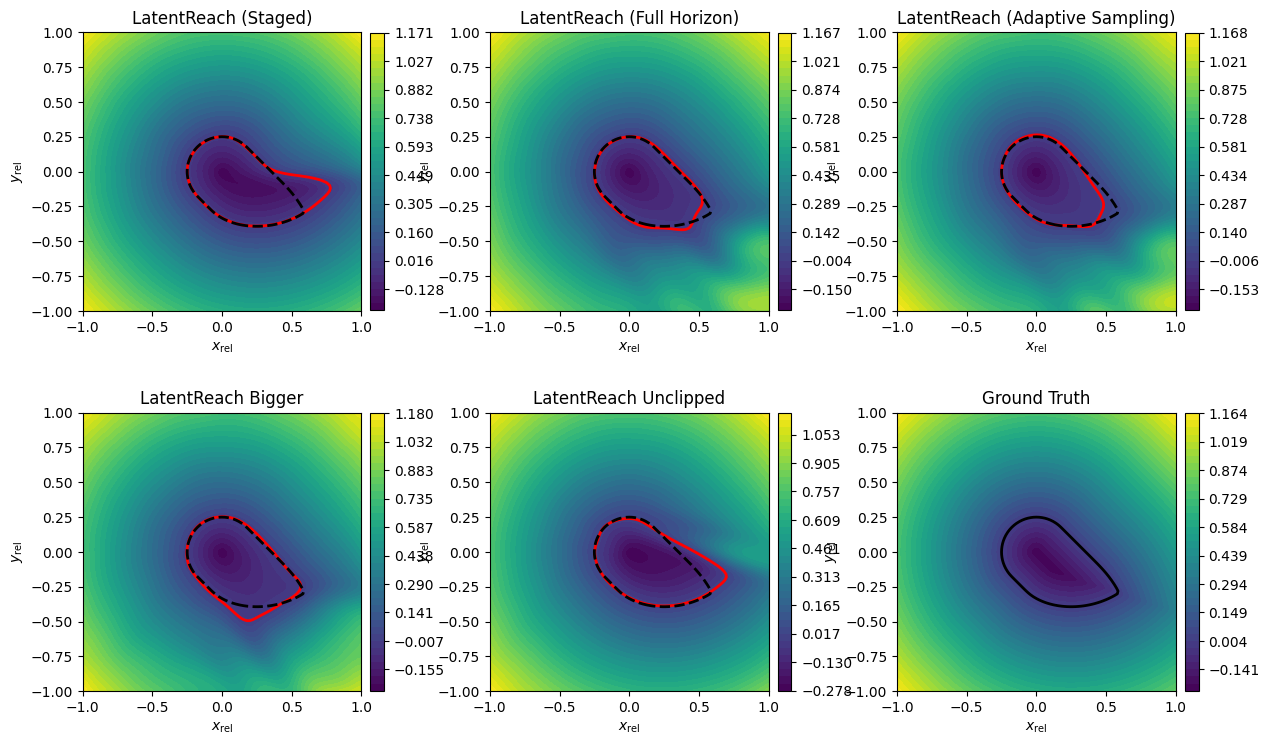

In [6]:
plot_air3d_comparison(tau=1.00, save=True)

In [7]:
# plot_air3d_overlay_row(taus=[0.10, 0.30, 0.60, 1.00], save=True)

In [8]:
# ----------------------------
# Air3D gradient + control metrics
# ----------------------------

def safe_sign(x, eps=1e-6):
    out = np.zeros_like(x)
    out[x > eps] = 1.0
    out[x < -eps] = -1.0
    return out


def take_air3d_psi_slice(arr3, axis_order, psi_idx):
    """
    Returns a [ny, nx] slice from a 3D Air3D array.

    axis_order should describe arr3's axes, e.g.
      ("x", "y", "psi")
      ("psi", "y", "x")
    """
    axis_order = tuple(axis_order)
    psi_axis = axis_order.index("psi")

    slicer = [slice(None)] * 3
    slicer[psi_axis] = psi_idx
    arr2 = arr3[tuple(slicer)]

    remaining = [a for a in axis_order if a != "psi"]

    if remaining == ["y", "x"]:
        return arr2

    if remaining == ["x", "y"]:
        return arr2.T

    raise ValueError(f"Unsupported Air3D axis order after slicing psi: {remaining}")


def infer_air3d_gt_axis_order(V3, V_gt_slice_ref, psi_idx):
    """
    Infers the axis order of solve_air3d_relative output by comparing to
    build_air3d_gt_slice(...), which your notebook already uses.
    """
    candidates = [
        ("x", "y", "psi"),
        ("y", "x", "psi"),
        ("psi", "y", "x"),
        ("psi", "x", "y"),
        ("x", "psi", "y"),
        ("y", "psi", "x"),
    ]

    best_order = None
    best_err = np.inf

    for order in candidates:
        try:
            cand = take_air3d_psi_slice(V3, order, psi_idx)
            if cand.shape != V_gt_slice_ref.shape:
                continue

            err = float(np.nanmean((cand - V_gt_slice_ref) ** 2))

            if err < best_err:
                best_err = err
                best_order = order

        except Exception:
            pass

    if best_order is None:
        raise RuntimeError(
            f"Could not infer GT axis order. "
            f"V3 shape={V3.shape}, reference slice shape={V_gt_slice_ref.shape}"
        )

    return best_order

def compute_air3d_gt_value_and_grad_slice(
    tau=1.0,
    cfg=None,
    psi_slice=None,
    nx=None,
    ny=None,
    npsi=None,
):
    """
    Computes Air3D ground truth value and physical-coordinate gradients.

    Returns:
      X, Y:      [ny, nx]
      V_gt:      [ny, nx]
      grad_gt:   [ny, nx, 3], ordered as [dV/dx, dV/dy, dV/dpsi]
    """
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slice is None:
        psi_slice = getattr(cfg, "psi_slice", 0.0)

    if nx is None:
        nx = cfg.x_discretization

    if ny is None:
        ny = cfg.y_discretization

    if npsi is None:
        npsi = cfg.psi_discretization

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], nx, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], ny, dtype=np.float32)
    psi = np.linspace(cfg.psi_bounds[0], cfg.psi_bounds[1], npsi, dtype=np.float32)

    psi_idx = int(np.argmin(np.abs(psi - float(psi_slice))))

    gt = solve_air3d_relative(
        tau_steps=[float(tau)],
        xr_discretization=nx,
        yr_discretization=ny,
        theta_discretization=npsi,
        xr_bounds=cfg.x_bounds,
        yr_bounds=cfg.y_bounds,
        theta_bounds=cfg.psi_bounds,
        vp=cfg.vp,
        ve=cfg.ve,
        u_bound=cfg.u_bound,
        d_bound=cfg.d_bound,
        radius=cfg.beta,
    )

    V3 = np.asarray(gt[-1])

    V_gt_slice_ref = build_air3d_gt_slice(
        gt_values_3d=V3,
        psi_bounds=cfg.psi_bounds,
        psi_slice=float(psi_slice),
    )

    axis_order = infer_air3d_gt_axis_order(
        V3=V3,
        V_gt_slice_ref=V_gt_slice_ref,
        psi_idx=psi_idx,
    )

    spacings = {
        "x": float(x[1] - x[0]),
        "y": float(y[1] - y[0]),
        "psi": float(psi[1] - psi[0]),
    }

    grad_by_axis = np.gradient(
        V3,
        *(spacings[a] for a in axis_order),
        edge_order=2,
    )

    grad_components = {
        axis_order[i]: grad_by_axis[i]
        for i in range(3)
    }

    V_gt = take_air3d_psi_slice(V3, axis_order, psi_idx)
    dV_dx = take_air3d_psi_slice(grad_components["x"], axis_order, psi_idx)
    dV_dy = take_air3d_psi_slice(grad_components["y"], axis_order, psi_idx)
    dV_dpsi = take_air3d_psi_slice(grad_components["psi"], axis_order, psi_idx)

    grad_gt = np.stack([dV_dx, dV_dy, dV_dpsi], axis=-1)

    X, Y = np.meshgrid(x, y, indexing="xy")

    return X, Y, V_gt, grad_gt

def evaluate_air3d_value_and_grad_on_slice(
    model,
    cfg,
    tau,
    psi_slice=None,
    nx=None,
    ny=None,
    device=DEVICE,
    chunk_size=4096,
):
    """
    Evaluates an Air3D LatentReach model and its physical-coordinate gradients.

    Returns:
      X, Y:        [ny, nx]
      V_pred:      [ny, nx]
      grad_pred:   [ny, nx, 3], ordered as [dV/dx, dV/dy, dV/dpsi]
    """
    if psi_slice is None:
        psi_slice = getattr(cfg, "psi_slice", 0.0)

    if nx is None:
        nx = cfg.x_discretization

    if ny is None:
        ny = cfg.y_discretization

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], nx, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    x_flat = X.reshape(-1).astype(np.float32)
    y_flat = Y.reshape(-1).astype(np.float32)

    x_net, y_net, psi_net = scale_air3d_states_to_net(
        x_flat,
        y_flat,
        float(psi_slice),
        cfg,
    )

    tau_net = np.full_like(x_flat, float(tau), dtype=np.float32)

    if getattr(cfg, "scale_time_to_01", False):
        tau_net = tau_net / cfg.T

    xt_np = np.stack([x_net, y_net, psi_net, tau_net], axis=-1)

    vals = []
    grads = []

    model.eval()

    for start in range(0, xt_np.shape[0], chunk_size):
        end = min(start + chunk_size, xt_np.shape[0])

        xt = torch.tensor(
            xt_np[start:end],
            dtype=torch.float32,
            device=device,
        ).clone().detach().requires_grad_(True)

        tau_phys = torch.full(
            (end - start,),
            float(tau),
            dtype=torch.float32,
            device=device,
        )

        V = model.compute_value_at_xt(xt, tau_phys)[0].squeeze(-1)

        dV_dxt = torch.autograd.grad(
            V,
            xt,
            grad_outputs=torch.ones_like(V),
            retain_graph=False,
            create_graph=False,
        )[0]

        grad_net = dV_dxt[:, :3]
        grad_phys = grad_net.clone()

        if getattr(cfg, "scale_to_minus1_1", True):
            grad_phys[:, 0] = grad_net[:, 0] * (
                2.0 / (cfg.x_bounds[1] - cfg.x_bounds[0])
            )
            grad_phys[:, 1] = grad_net[:, 1] * (
                2.0 / (cfg.y_bounds[1] - cfg.y_bounds[0])
            )

            # In your scale_air3d_states_to_net:
            # psi_net = psi_phys / (1.2 * pi)
            grad_phys[:, 2] = grad_net[:, 2] * (1.0 / (1.2 * np.pi))

        vals.append(V.detach().cpu().numpy())
        grads.append(grad_phys.detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(ny, nx)
    grad_pred = np.concatenate(grads, axis=0).reshape(ny, nx, 3)

    return X, Y, V_pred, grad_pred

def optimal_air3d_control_from_grad(X, Y, grad, cfg, eps=1e-6):
    """
    Air3D relative dynamics convention:

      xdot   = -vp + ve*cos(psi) + u*y
      ydot   =       ve*sin(psi) - u*x
      psidot = d - u

    Hamiltonian terms:

      u * (y*p_x - x*p_y - p_psi) + d * p_psi

    This assumes the controller minimizes and disturbance maximizes.
    If your residual uses the opposite convention, flip both signs below.
    """
    p_x = grad[..., 0]
    p_y = grad[..., 1]
    p_psi = grad[..., 2]

    u_switch = Y * p_x - X * p_y - p_psi
    d_switch = p_psi

    u_star = -cfg.u_bound * safe_sign(u_switch, eps=eps)
    d_star =  cfg.d_bound * safe_sign(d_switch, eps=eps)

    return u_star, d_star


def air3d_gradient_and_control_metrics(
    X,
    Y,
    V_pred,
    grad_pred,
    V_gt,
    grad_gt,
    cfg,
    boundary_band=0.05,
):
    grad_err = grad_pred - grad_gt

    grad_l2 = np.linalg.norm(grad_err, axis=-1)
    grad_gt_norm = np.linalg.norm(grad_gt, axis=-1)
    grad_pred_norm = np.linalg.norm(grad_pred, axis=-1)

    dot = np.sum(grad_pred * grad_gt, axis=-1)
    cosine = dot / (grad_pred_norm * grad_gt_norm + 1e-8)

    u_pred, d_pred = optimal_air3d_control_from_grad(X, Y, grad_pred, cfg)
    u_gt, d_gt = optimal_air3d_control_from_grad(X, Y, grad_gt, cfg)

    u_agree = u_pred == u_gt
    d_agree = d_pred == d_gt

    near_boundary = np.abs(V_gt) <= boundary_band
    all_mask = np.ones_like(V_gt, dtype=bool)

    def mean_on(mask, arr):
        if mask.sum() == 0:
            return np.nan
        return float(np.mean(arr[mask]))

    def frac_on(mask, arr):
        if mask.sum() == 0:
            return np.nan
        return float(np.mean(arr[mask]))

    metrics = {
        "grad_L2_MAE_all": mean_on(all_mask, grad_l2),
        "grad_L2_MAE_boundary": mean_on(near_boundary, grad_l2),

        "grad_cosine_all": mean_on(all_mask, cosine),
        "grad_cosine_boundary": mean_on(near_boundary, cosine),

        "u_agree_all": frac_on(all_mask, u_agree),
        "u_agree_boundary": frac_on(near_boundary, u_agree),

        "d_agree_all": frac_on(all_mask, d_agree),
        "d_agree_boundary": frac_on(near_boundary, d_agree),

        "boundary_fraction": float(near_boundary.mean()),
    }

    return metrics

def make_air3d_gradient_control_metrics_table(
    taus=[0.10, 0.30, 0.60, 1.00],
    nx=None,
    ny=None,
    npsi=None,
    boundary_band=0.05,
    reference_run="LatentReach (Staged)",
):
    rows = []

    cfg_ref = load_cfg_from_run(AIR_RUNS[reference_run])

    if nx is None:
        nx = cfg_ref.x_discretization

    if ny is None:
        ny = cfg_ref.y_discretization

    if npsi is None:
        npsi = cfg_ref.psi_discretization

    psi_slice = getattr(cfg_ref, "psi_slice", 0.0)

    for tau in taus:
        X_gt, Y_gt, V_gt, grad_gt = compute_air3d_gt_value_and_grad_slice(
            tau=tau,
            cfg=cfg_ref,
            psi_slice=psi_slice,
            nx=nx,
            ny=ny,
            npsi=npsi,
        )

        for display_name, run_dir in AIR_RUNS.items():
            ckpt_path = get_air3d_ckpt_path(display_name, tau)

            if ckpt_path is None:
                print(f"Skipping {display_name}: no checkpoint found")
                continue

            model, cfg, _ = load_air3d_checkpoint(ckpt_path, device=DEVICE)

            _, _, V_pred, grad_pred = evaluate_air3d_value_and_grad_on_slice(
                model=model,
                cfg=cfg,
                tau=tau,
                psi_slice=psi_slice,
                nx=nx,
                ny=ny,
                device=DEVICE,
            )

            metrics = air3d_gradient_and_control_metrics(
                X=X_gt,
                Y=Y_gt,
                V_pred=V_pred,
                grad_pred=grad_pred,
                V_gt=V_gt,
                grad_gt=grad_gt,
                cfg=cfg_ref,
                boundary_band=boundary_band,
            )

            metrics["tau"] = tau
            metrics["model"] = display_name
            metrics["ckpt"] = Path(ckpt_path).name

            rows.append(metrics)

    return pd.DataFrame(rows)


def save_air3d_gradient_control_metrics_table(
    taus=[0.10, 0.30, 0.60, 1.00],
    nx=None,
    ny=None,
    npsi=None,
    boundary_band=0.05,
    reference_run="LatentReach (Staged)",
):
    metrics_df = make_air3d_gradient_control_metrics_table(
        taus=taus,
        nx=nx,
        ny=ny,
        npsi=npsi,
        boundary_band=boundary_band,
        reference_run=reference_run,
    )

    csv_path = OUTPUT_DIR / "air3d_gradient_control_metrics.csv"
    metrics_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

    tex_path = OUTPUT_DIR / "air3d_gradient_control_metrics_table.tex"
    with open(tex_path, "w") as f:
        f.write(metrics_df.to_latex(index=False, escape=False))

    print("Saved:", tex_path)

    return metrics_df

In [9]:
grad_metrics_df = save_air3d_gradient_control_metrics_table(
    taus=[1.00],
    boundary_band=0.05,
)

grad_metrics_df

100%|##################################|  1.0000/1.0 [01:06<00:00, 66.97s/sim_s]


Loaded tau_1.00.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Loaded step_010600.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Loaded step_010000.pt with PNODE_SIREN
Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_gradient_control_metrics.csv
Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_gradient_control_metrics_table.tex


,grad_L2_MAE_all,grad_L2_MAE_boundary,grad_cosine_all,grad_cosine_boundary,u_agree_all,u_agree_boundary,d_agree_all,d_agree_boundary,boundary_fraction,tau,model,ckpt
0,0.126448,0.243790,0.966745,0.912259,0.706009,0.697509,0.481914,0.590747,0.055093,1.0,LatentReach (Staged),tau_1.00.pt
1,0.237670,0.208490,0.941279,0.966045,0.688854,0.818505,0.455740,0.578292,0.055093,1.0,LatentReach (Full Horizon),step_010000.pt
2,0.219578,0.223091,0.952702,0.979255,0.667091,0.811388,0.453975,0.612100,0.055093,1.0,LatentReach (Adaptive Sampling),step_010600.pt
3,0.209075,0.225327,0.967336,0.980606,0.652191,0.875445,0.447015,0.565836,0.055093,1.0,LatentReach Bigger,step_010000.pt
4,0.169256,0.348470,0.954797,0.903741,0.698363,0.701068,0.475248,0.496441,0.055093,1.0,LatentReach Unclipped,step_010000.pt


In [10]:
# ----------------------------
# value-function + BRT error table
# ----------------------------

def compute_air3d_value_brt_metrics(V_pred, V_gt):
    """
    Value metrics:
      MAE, MSE, RMSE, rel_L2, max_abs

    BRT metrics:
      pred_brt = V_pred <= 0
      gt_brt   = V_gt <= 0

      IoU: intersection / union
      BRT_error: 1 - IoU
      precision: predicted BRT correctness
      recall: GT BRT coverage
      F1: harmonic mean of precision/recall
      symdiff_frac: fraction of grid where BRT labels disagree
    """
    V_pred = np.asarray(V_pred)
    V_gt = np.asarray(V_gt)

    err = V_pred - V_gt

    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    max_abs = float(np.max(np.abs(err)))

    rel_l2 = float(
        np.linalg.norm(err.reshape(-1)) /
        (np.linalg.norm(V_gt.reshape(-1)) + 1e-12)
    )

    pred_brt = V_pred <= 0.0
    gt_brt = V_gt <= 0.0

    inter = np.logical_and(pred_brt, gt_brt).sum()
    union = np.logical_or(pred_brt, gt_brt).sum()

    pred_area = pred_brt.sum()
    gt_area = gt_brt.sum()

    iou = float(inter / max(union, 1))
    brt_error = float(1.0 - iou)

    precision = float(inter / max(pred_area, 1))
    recall = float(inter / max(gt_area, 1))

    f1 = float(
        2.0 * precision * recall /
        max(precision + recall, 1e-12)
    )

    false_pos_frac = float(np.logical_and(pred_brt, ~gt_brt).mean())
    false_neg_frac = float(np.logical_and(~pred_brt, gt_brt).mean())
    symdiff_frac = float(np.logical_xor(pred_brt, gt_brt).mean())

    return {
        "value_MAE": mae,
        "value_MSE": mse,
        "value_RMSE": rmse,
        "value_rel_L2": rel_l2,
        "value_max_abs": max_abs,

        "BRT_IoU": iou,
        "BRT_error_1_minus_IoU": brt_error,
        "BRT_precision": precision,
        "BRT_recall": recall,
        "BRT_F1": f1,
        "BRT_symdiff_frac": symdiff_frac,
        "BRT_false_pos_frac": false_pos_frac,
        "BRT_false_neg_frac": false_neg_frac,

        "pred_BRT_area_frac": float(pred_brt.mean()),
        "gt_BRT_area_frac": float(gt_brt.mean()),
    }

def make_air3d_value_brt_error_table(
    taus=[0.10, 0.30, 0.60, 1.00],
    reference_run="LatentReach (Staged)",
):
    rows = []

    cfg_ref = load_cfg_from_run(AIR_RUNS[reference_run])

    psi_slice = cfg_ref.psi_slice
    nx = cfg_ref.x_discretization
    ny = cfg_ref.y_discretization

    for tau in taus:
        X_gt, Y_gt, V_gt = compute_air3d_ground_truth_slice(
            tau=tau,
            cfg=cfg_ref,
        )

        for display_name, run_dir in AIR_RUNS.items():
            ckpt_path = get_air3d_ckpt_path(display_name, tau)

            if ckpt_path is None:
                print(f"Skipping {display_name}: no checkpoint found")
                continue

            print(f"Evaluating {display_name}, tau={tau:.2f}, ckpt={ckpt_path.name}")

            model, cfg, _ = load_air3d_checkpoint(
                ckpt_path,
                device=DEVICE,
            )

            X, Y, V_pred = evaluate_air3d_on_slice(
                model=model,
                cfg=cfg,
                tau=tau,
                psi_slice=psi_slice,
                nx=nx,
                ny=ny,
                device=DEVICE,
            )

            metrics = compute_air3d_value_brt_metrics(
                V_pred=V_pred,
                V_gt=V_gt,
            )

            metrics["tau"] = float(tau)
            metrics["model"] = display_name
            metrics["ckpt"] = Path(ckpt_path).name

            rows.append(metrics)

    return pd.DataFrame(rows)

def save_air3d_value_brt_error_table(
    taus=[0.10, 0.30, 0.60, 1.00],
    reference_run="LatentReach (Staged)",
):
    metrics_df = make_air3d_value_brt_error_table(
        taus=taus,
        reference_run=reference_run,
    )

    csv_path = OUTPUT_DIR / "air3d_value_brt_error_metrics.csv"
    metrics_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

    tex_path = OUTPUT_DIR / "air3d_value_brt_error_metrics.tex"
    with open(tex_path, "w") as f:
        f.write(metrics_df.to_latex(index=False, escape=False))

    print("Saved:", tex_path)

    return metrics_df

In [ ]:
value_brt_df = save_air3d_value_brt_error_table(
    taus=[1.00],
    reference_run="LatentReach (Staged)",
)

value_brt_df

  4%|#3                                |  0.0401/1.0 [00:02<01:05, 67.81s/sim_s]